In [1]:
import sys
import os
# Add parent directory to path to import dolphain if not installed
sys.path.append('..')

import dolphain
from dolphain import getData, build_catalog
import datetime
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

/Users/mjhaas/code/dolphain/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Build a Catalog

First, we need to index the files. For this demo, we'll build a mini-catalog targeting a specific buoy directory to save time. In production, you would run `build_catalog()` once for the whole dataset.

In [2]:
# Target a specific folder with .200 files
target_pattern = "datasets/ColorSynth/GoMRI-17/2017_South/BUOY200/*.200"
catalog_file = "demo_catalog.csv"

print("Building catalog...")
catalog_df = build_catalog(output_file=catalog_file, path_pattern=target_pattern)
print(f"Catalog ready with {len(catalog_df)} files.")
catalog_df.head()

Building catalog...
Scanning ColorSynth/GoMRI-17...
Globbing all files (this may take a moment)...
Found 1000 relevant files. Processing headers...
Processed 0/1000
Processed 10/1000
Processed 20/1000
Processed 30/1000
Processed 40/1000
Processed 50/1000
Processed 60/1000
Processed 70/1000
Processed 80/1000
Processed 90/1000
Processed 100/1000
Processed 110/1000
Processed 120/1000
Processed 130/1000
Processed 140/1000
Processed 150/1000
Processed 160/1000
Processed 170/1000
Processed 180/1000
Processed 190/1000
Processed 200/1000
Processed 210/1000
Processed 220/1000
Processed 230/1000
Processed 240/1000
Processed 250/1000
Processed 260/1000
Processed 270/1000
Processed 280/1000
Processed 290/1000
Processed 300/1000
Processed 310/1000
Processed 320/1000
Processed 330/1000
Processed 340/1000
Processed 350/1000
Processed 360/1000
Processed 370/1000
Processed 380/1000
Processed 390/1000
Processed 400/1000
Processed 410/1000
Processed 420/1000
Processed 430/1000
Processed 440/1000
Processe

,file_path,filename,start_time,end_time,duration,size,n_samples
0,datasets/ColorSynth/GoMRI-17/2017_South/BUOY20...,7178E5DC.200,2017-06-28 00:20:34.757219,2017-06-28 00:20:56.090552,21.333333,8388608,4096000
1,datasets/ColorSynth/GoMRI-17/2017_South/BUOY20...,7178E5DD.200,2017-06-28 00:20:56.088906,2017-06-28 00:21:17.422239,21.333333,8388608,4096000
2,datasets/ColorSynth/GoMRI-17/2017_South/BUOY20...,7178E5DE.200,2017-06-28 00:21:17.420594,2017-06-28 00:21:38.753927,21.333333,8388608,4096000
3,datasets/ColorSynth/GoMRI-17/2017_South/BUOY20...,7178E5DF.200,2017-06-28 00:21:38.752281,2017-06-28 00:22:00.085614,21.333333,8388608,4096000
4,datasets/ColorSynth/GoMRI-17/2017_South/BUOY20...,7178E5E0.200,2017-06-28 00:22:00.083969,2017-06-28 00:22:21.417302,21.333333,8388608,4096000


## 2. Fetch Data Across Boundaries

We'll select a time range that spans across two files. The `getData` function will automatically handle opening multiple files and stitching the samples together.

In [11]:
if not catalog_df.empty:
    # Get the end time of the first file
    first_file_end = catalog_df.iloc[700]["end_time"]
    
    # Ensure it's a datetime object
    if isinstance(first_file_end, str):
        first_file_end = pd.to_datetime(first_file_end)
        
    # Define a range: 5 seconds before the first file ends, lasting 10 seconds
    # This ensures we cross into the second file
    start_time = first_file_end - datetime.timedelta(seconds=5)
    duration = 90.0
    
    print(f"Requesting {duration}s of data starting at {start_time}")
    
    # Fetch the data
    audio_data = getData(
        source="GoMRI-17", 
        start_time=start_time, 
        length_seconds=duration,
        catalog_path=catalog_file
    )
    
    print(f"Retrieved {len(audio_data)} samples")
    print(f"Expected samples: {int(duration * 192000)}")

Requesting 90.0s of data starting at 2017-06-28 04:29:43.266802
Retrieved 17280000 samples
Expected samples: 17280000


## 3. Visualize Results

Plot the waveform and spectrogram to verify the data is continuous.

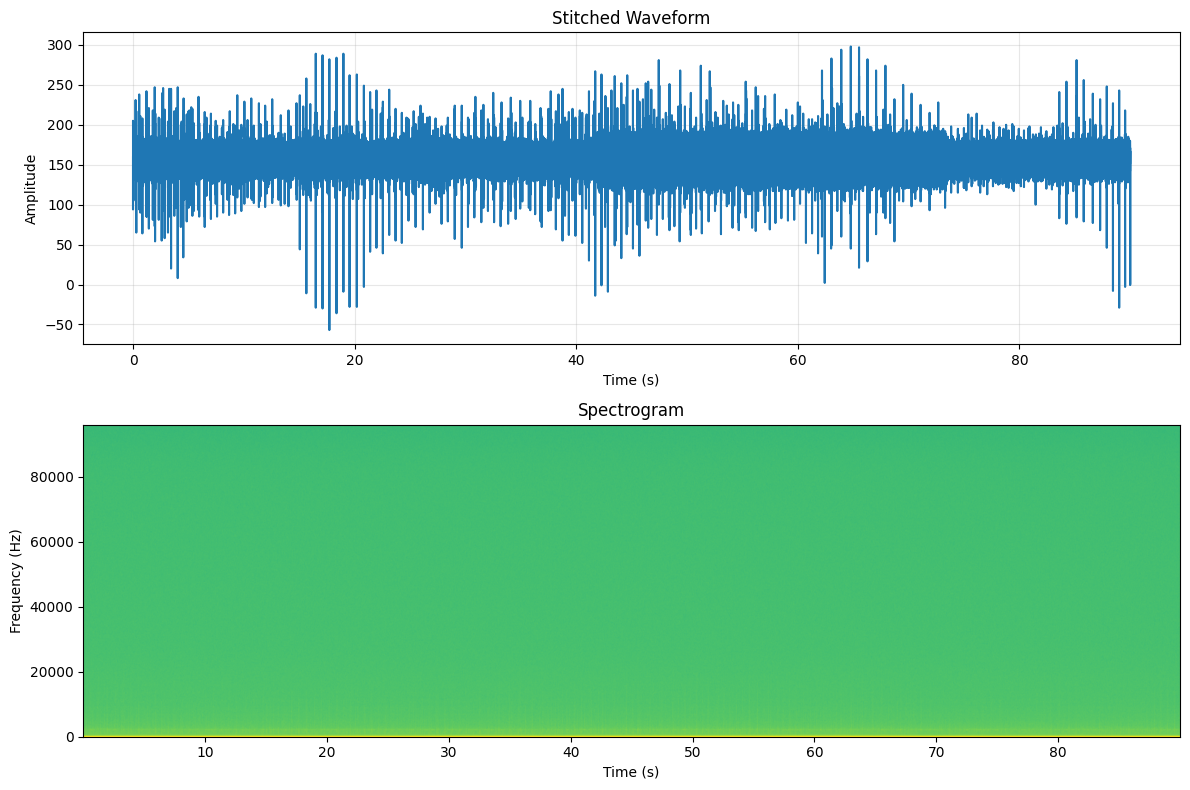

In [12]:
if 'audio_data' in locals() and len(audio_data) > 0:
    plt.figure(figsize=(12, 8))

    # Waveform
    plt.subplot(2, 1, 1)
    plt.plot(np.linspace(0, duration, len(audio_data)), audio_data)
    plt.title("Stitched Waveform")
    plt.xlabel("Time (s)")
    plt.ylabel("Amplitude")
    plt.grid(True, alpha=0.3)

    # Spectrogram
    plt.subplot(2, 1, 2)
    plt.specgram(audio_data, Fs=192000, NFFT=1024, noverlap=512, cmap='viridis')
    plt.title("Spectrogram")
    plt.ylabel("Frequency (Hz)")
    plt.xlabel("Time (s)")

    plt.tight_layout()
    plt.show()
else:
    print("No data to plot.")